In [7]:
import os
import numpy as np
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

In [8]:
emb_dir = os.path.join('..', 'embedding', 'word_embeddings_cleaned')

In [ ]:
# Function to read .vec files and return the vectors as a numpy array
def read_vec_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        # Read the first line to get dimensions
        header = f.readline().split()
        n_vectors = int(header[0])
        dim = int(header[1])
        
        print(f"Loading {n_vectors} vectors of dimension {dim}...")

        # usecols=range(1, dim + 1) ensures we skip the label 
        # and grab all 'dim' numerical values.
        vectors = np.loadtxt(f, delimiter=' ', usecols=range(1, dim + 1))
        
    print(f"Final shape: {vectors.shape}")
    return vectors

In [ ]:
# Function to estimate similarity percentiles by sampling pairs of vectors
def estimate_similarity_percentiles(vectors, percentiles, n_samples=2_000_000, seed=42):
    rng = np.random.default_rng(seed)
    n = vectors.shape[0]

    i = rng.integers(0, n, size=n_samples)
    j = rng.integers(0, n, size=n_samples)

    mask = i != j
    
    # compute cosine sim
    sims = np.sum(vectors[i[mask]] * vectors[j[mask]], axis=1)

    return np.percentile(sims, percentiles)

# Function to compute degrees blockwise to save memory
def compute_degrees_blockwise(vectors, threshold, block_size=1024):
    n = vectors.shape[0]
    degrees = np.zeros(n, dtype=np.int32)

    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        block = vectors[start:end]

        sims = block @ vectors.T  # (block_size, n)

        degrees[start:end] = np.sum(sims >= threshold, axis=1)

    # remove self-loops
    degrees -= 1
    return degrees

In [ ]:
# Main function to process all snapshots and plot degree distributions
def print_similarity_stats_sustainable(emb_dir, perc=99):
    for i in range(1, 8):
        f = f'fasttext_snap{i}_filt.vec'
        file_path = os.path.join(emb_dir, f)

        print(f"\n--- Processing: {f} ---")

        vectors = read_vec_file(file_path).astype("float32")
        vectors = normalize(vectors, axis=1)

        quartiles = estimate_similarity_percentiles(
            vectors, [50, 75, 90, 95, 99, 99.5]
        )

        print(f"50%: {quartiles[0]:.4f}")
        print(f"75%: {quartiles[1]:.4f}")
        print(f"90%: {quartiles[2]:.4f}")
        print(f"95%: {quartiles[3]:.4f}")
        print(f"99%: {quartiles[4]:.4f}")
        print(f"99.5%: {quartiles[5]:.4f}")

        threshold_value = quartiles[-2 if perc == 99 else -1]

        degrees = compute_degrees_blockwise(
            vectors, threshold_value, block_size=1024
        )

        unique_degrees, counts = np.unique(degrees, return_counts=True)

        # Keep bins as before
        bin_width = 50
        max_degree = degrees.max()
        bins = np.arange(0, max_degree + bin_width, bin_width)

        _, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Scatter plot (unchanged)
        axes[0].scatter(unique_degrees, counts, alpha=0.7, s=5)
        axes[0].set_xlabel("Number of edges (degree)")
        axes[0].set_ylabel("Number of nodes")
        axes[0].set_title(f"Degree distribution of snapshot {i} (scatter) - {perc}th percentil cut")
        axes[0].set_yscale("log")
        axes[0].grid(True, linestyle="--", alpha=0.7)

        # Histogram with spacing
        axes[1].hist(
            degrees,
            bins=bins,
            width=bin_width * 0.8,  # 90% of the bin width, leaving 10% gap
        )

        # Add vertical line at median
        median_degree = np.median(degrees)
        axes[1].axvline(
            median_degree,
            color='red', 
            linestyle='--', 
            linewidth=2,
            label=f"Median: {median_degree:.0f}"
        )
        
        # Add vertical line at mean
        mean_degree = np.mean(degrees)
        axes[1].axvline(
            mean_degree,
            color='orange', 
            linestyle='--', 
            linewidth=2,
            label=f"Mean: {mean_degree:.0f}"
        )
        
        axes[1].set_xlabel("Number of edges (degree)")
        axes[1].set_ylabel("Number of nodes")
        axes[1].set_title(f"Degree distribution of snapshot {i} (histogram) - {perc}th percentil cut")
        axes[1].set_yscale("log")
        axes[1].grid(True, linestyle="--", alpha=0.7)
        axes[1].legend()

        plt.tight_layout()
        plt.show()


--- Processing: fasttext_snap1_filt.vec ---
Loading 35311 vectors of dimension 100...
Final shape: (35311, 100)
50%: 0.3291
75%: 0.4043
90%: 0.4743
95%: 0.5167
99%: 0.5969
99.5%: 0.6261


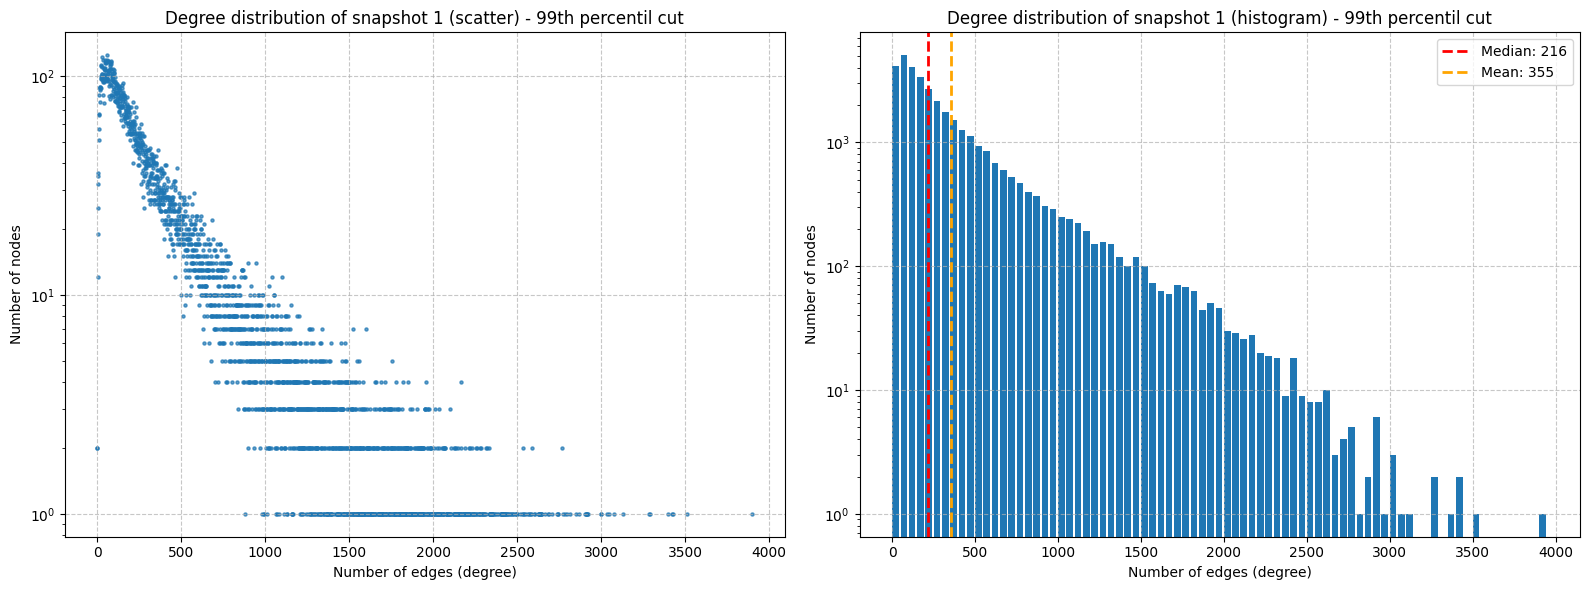


--- Processing: fasttext_snap2_filt.vec ---
Loading 28019 vectors of dimension 100...
Final shape: (28019, 100)
50%: 0.2345
75%: 0.3080
90%: 0.3811
95%: 0.4276
99%: 0.5194
99.5%: 0.5541


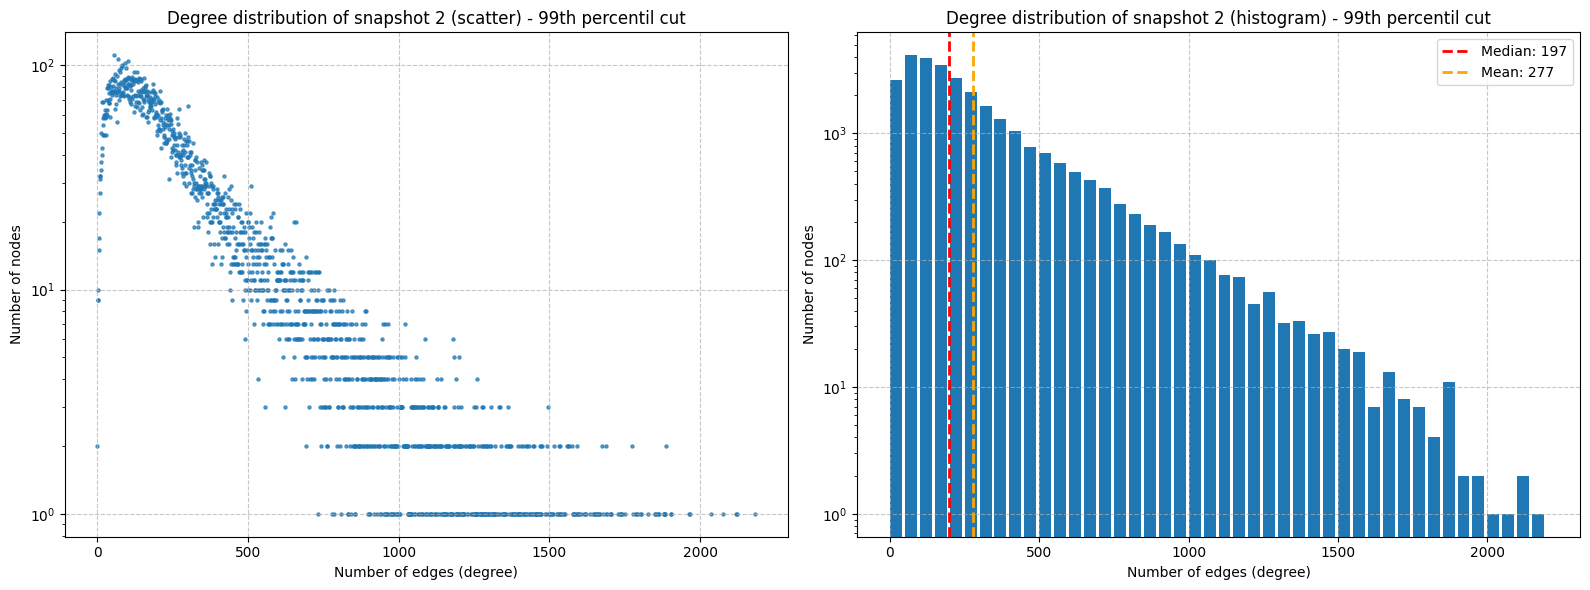


--- Processing: fasttext_snap3_filt.vec ---
Loading 28031 vectors of dimension 100...
Final shape: (28031, 100)
50%: 0.2347
75%: 0.3087
90%: 0.3816
95%: 0.4278
99%: 0.5183
99.5%: 0.5526


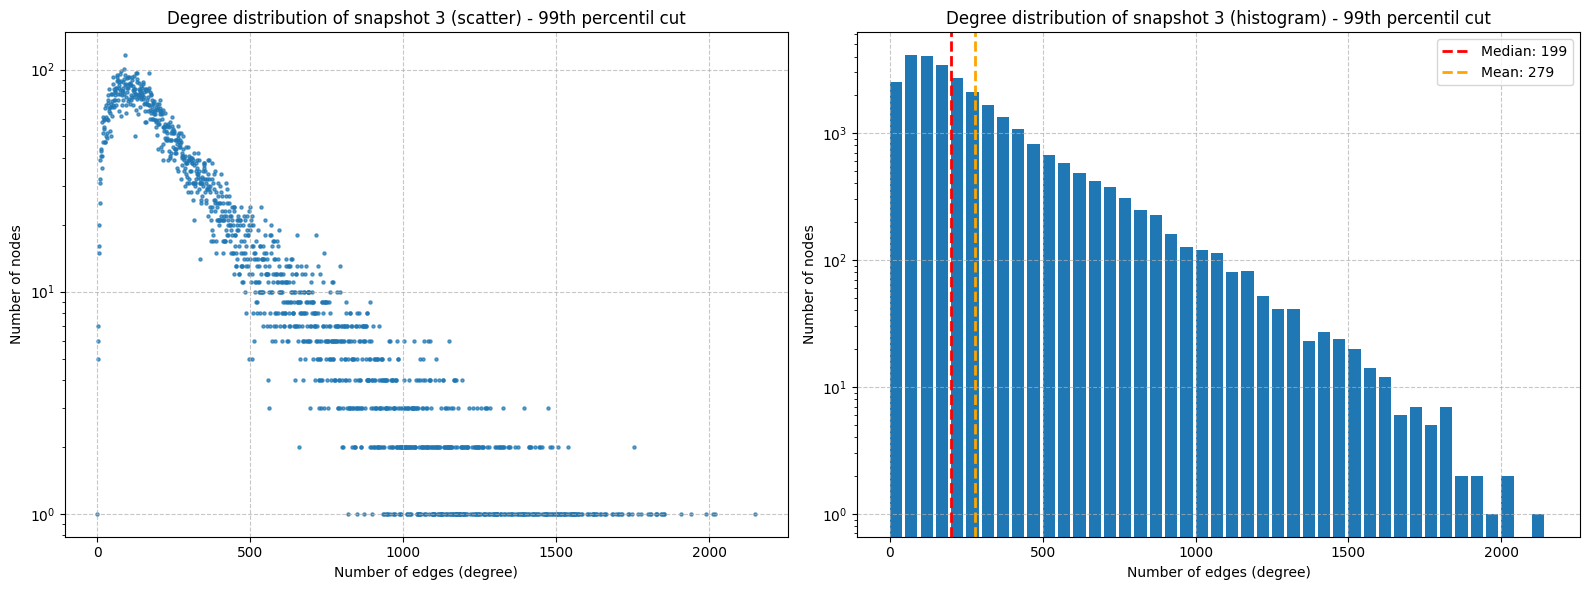


--- Processing: fasttext_snap4_filt.vec ---
Loading 34951 vectors of dimension 100...
Final shape: (34951, 100)
50%: 0.2487
75%: 0.3222
90%: 0.3934
95%: 0.4378
99%: 0.5241
99.5%: 0.5562


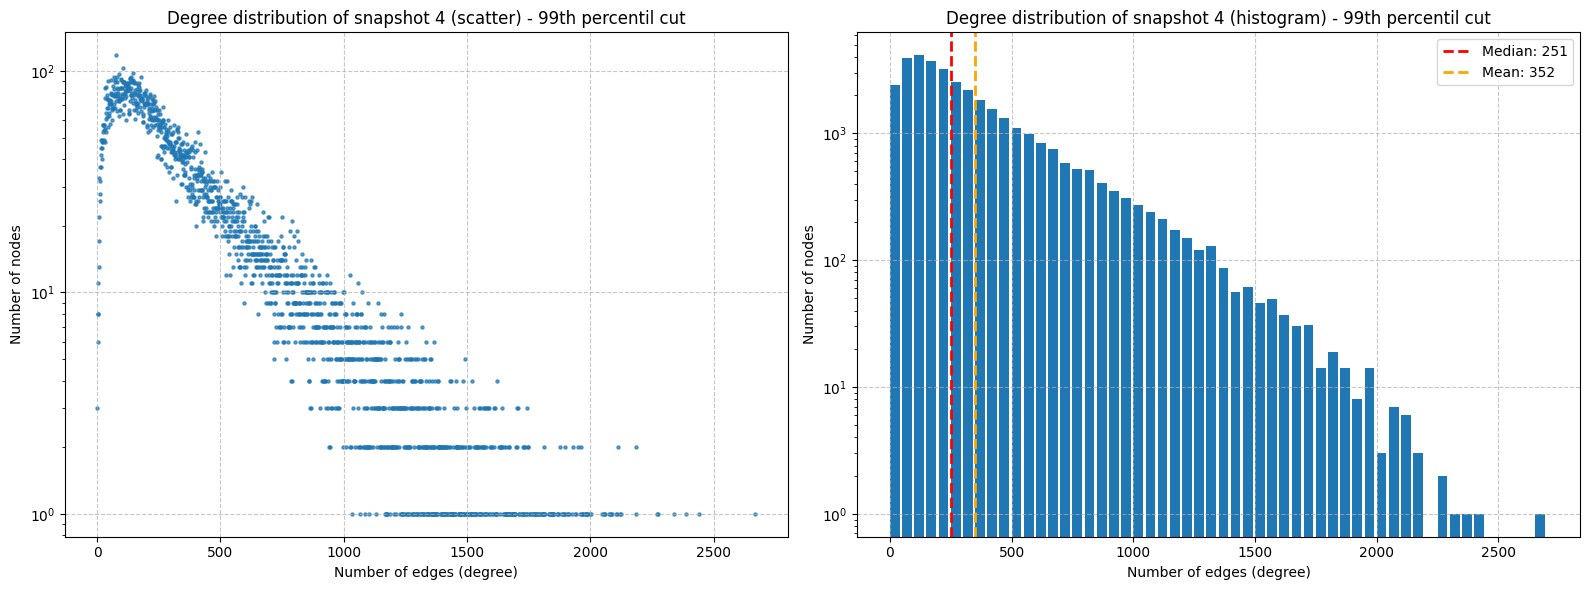


--- Processing: fasttext_snap5_filt.vec ---
Loading 37681 vectors of dimension 100...
Final shape: (37681, 100)
50%: 0.2519
75%: 0.3246
90%: 0.3950
95%: 0.4390
99%: 0.5238
99.5%: 0.5560


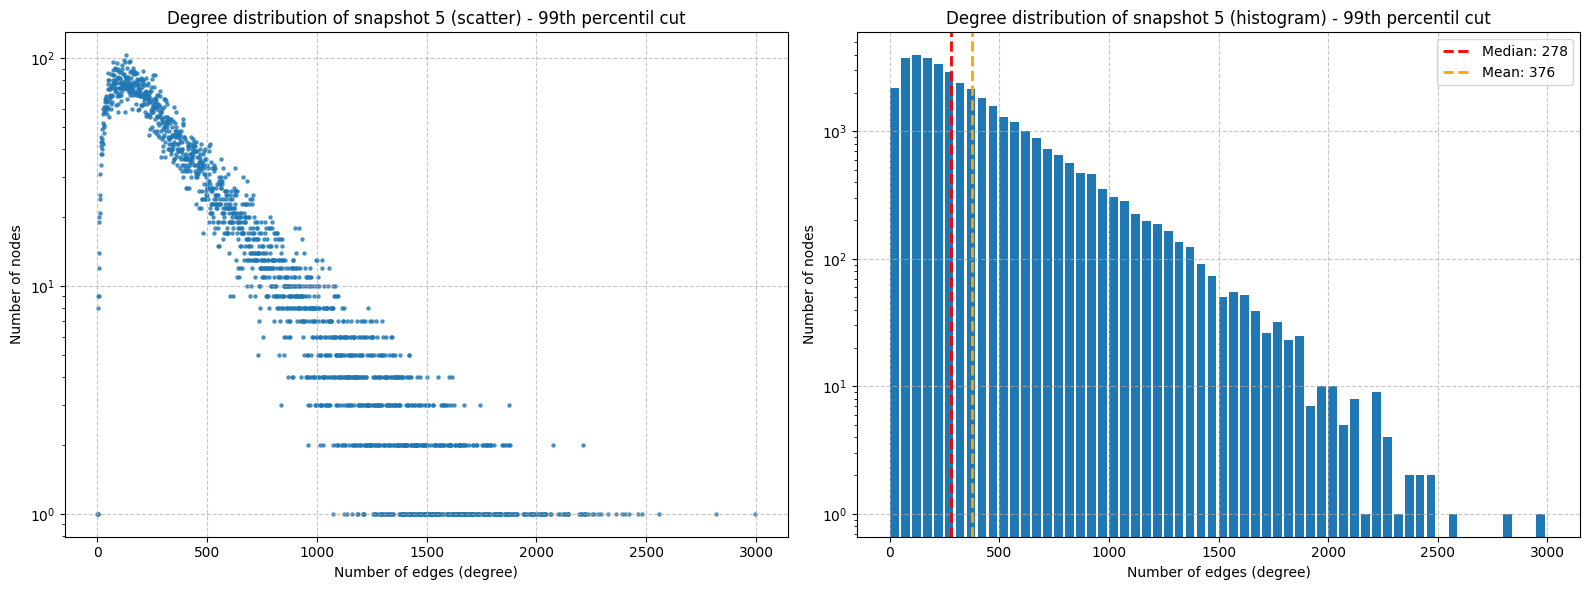


--- Processing: fasttext_snap6_filt.vec ---
Loading 52979 vectors of dimension 100...
Final shape: (52979, 100)
50%: 0.2560
75%: 0.3313
90%: 0.4028
95%: 0.4468
99%: 0.5303
99.5%: 0.5612


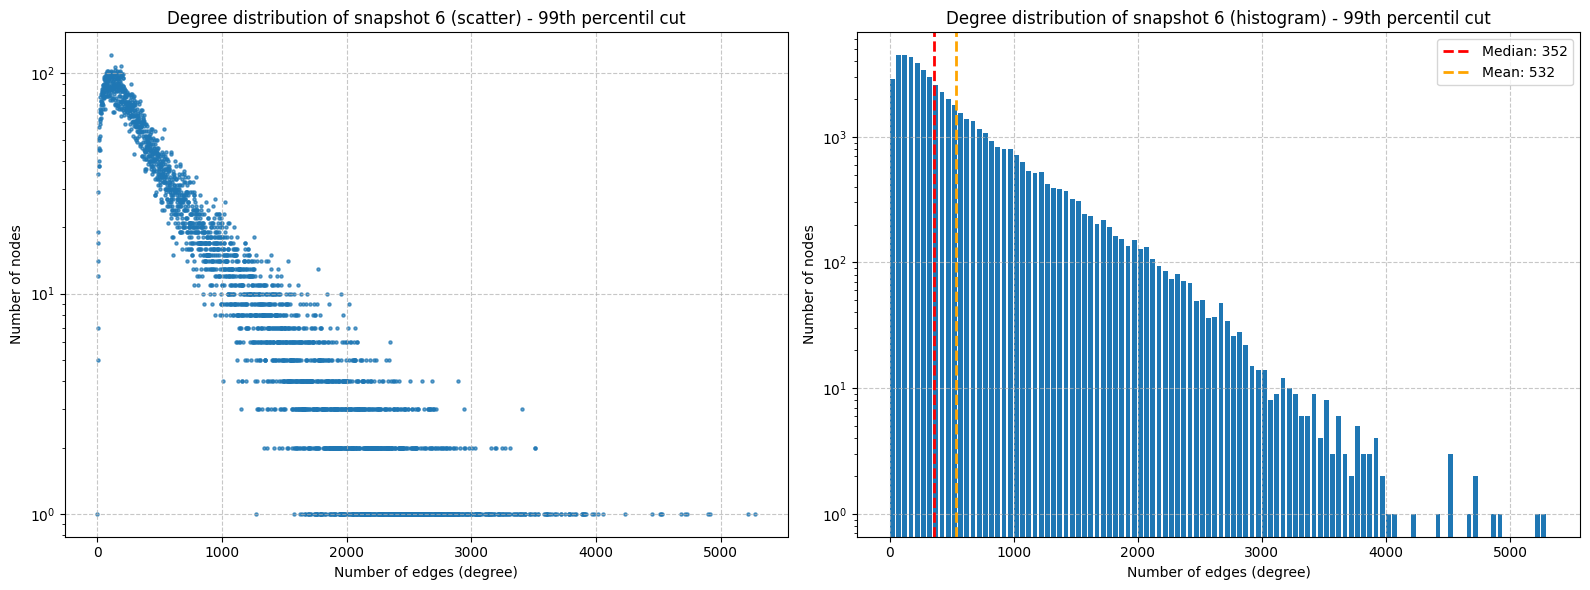


--- Processing: fasttext_snap7_filt.vec ---
Loading 38845 vectors of dimension 100...
Final shape: (38845, 100)
50%: 0.2399
75%: 0.3149
90%: 0.3877
95%: 0.4330
99%: 0.5198
99.5%: 0.5513


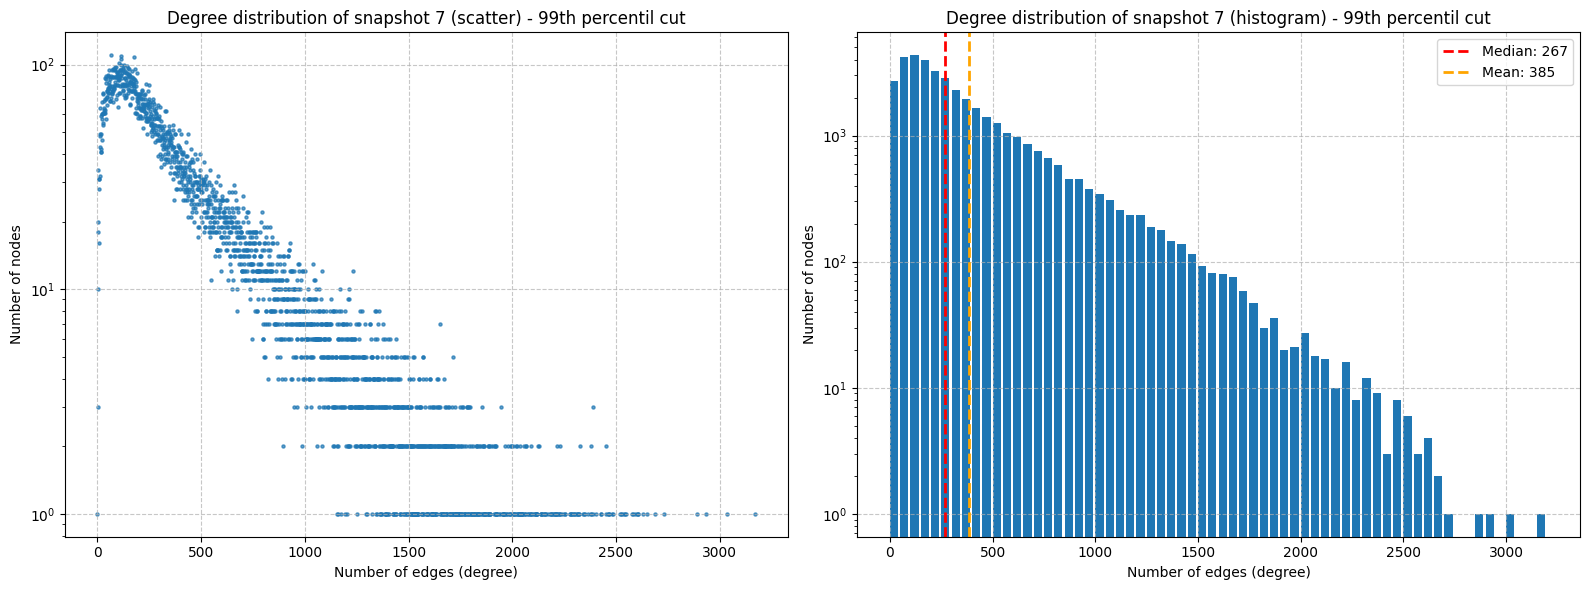

In [13]:
print_similarity_stats_sustainable(emb_dir, 99)

In [ ]:
# Function to save edges above a certain similarity threshold to a TSV file
def save_nodes_edges(
    emb_dir,
    out_dir,
    perc=99,
    block_size=1024
):
    os.makedirs(out_dir, exist_ok=True)

    for snap in range(1, 8):
        fname = f"fasttext_snap{snap}_filt.vec"
        file_path = os.path.join(emb_dir, fname)

        print(f"\n--- Processing: {fname} ---")

        vectors = read_vec_file(file_path)
        vectors = vectors.astype("float32")
        vectors = normalize(vectors, axis=1)

        n = vectors.shape[0]

        # percentile threshold (Monte Carlo estimate)
        threshold = estimate_similarity_percentiles(vectors, [perc])[0]
        print(f"Similarity threshold @ p{perc}: {threshold:.4f}")

        out_path = os.path.join(out_dir, f"edges_snap{snap}_p{perc}.tsv")

        with open(out_path, "w") as f_out:
            f_out.write("i\tj\tsimilarity\n")

            for start in range(0, n, block_size):
                end = min(start + block_size, n)
                block = vectors[start:end]

                # cosine similarities
                sims = block @ vectors.T  # (block_size, n)

                # indices where similarity exceeds threshold
                ii, jj = np.where(sims > threshold)

                for bi, j in zip(ii, jj):
                    i = start + bi

                    # remove self-edges
                    if i >= j:
                        continue

                    sim = sims[bi, j]
                    f_out.write(f"{i}\t{j}\t{sim:.6f}\n")

        print(f"Saved edges to {out_path}")

In [ ]:
out_dir = 'edges'

save_nodes_edges(emb_dir, out_dir)